# Random Trading Strategy on GOOG

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import random

plt.style.use('default')

In [2]:
start_date = '2001-01-01'
end_date = '2018-01-01'

goog_data = yf.download(
    'GOOG',
    start=start_date,
    end=end_date,
    auto_adjust=True
)

goog_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2004-08-19,2.477292,2.569134,2.369154,2.468896,897427216
2004-08-20,2.674063,2.693073,2.481242,2.493833,458857488
2004-08-23,2.700973,2.801704,2.692332,2.734303,366857939
2004-08-24,2.589132,2.755288,2.557036,2.746401,306396159
2004-08-25,2.617030,2.666409,2.564690,2.591354,184645512


In [3]:
random.seed(6666)

In [4]:
signals = pd.DataFrame(index=goog_data.index)
signals['signal'] = [random.randint(0,1) for _ in range(len(signals))]
signals['orders'] = signals['signal'].diff()

signals.head()

,signal,orders
Date,,
2004-08-19,0,NaN
2004-08-20,0,0.0
2004-08-23,0,0.0
2004-08-24,1,1.0
2004-08-25,1,0.0


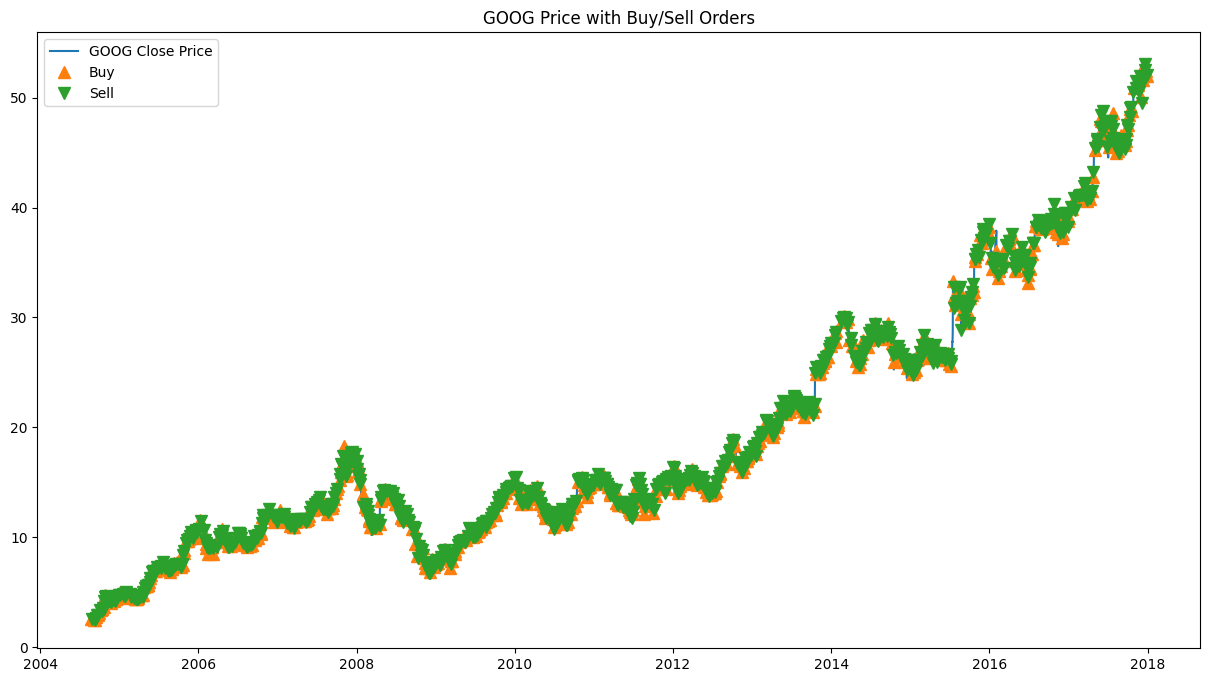

In [5]:
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(goog_data.index, goog_data['Close'], label='GOOG Close Price')

ax.plot(
    signals.loc[signals['orders']==1].index,
    goog_data.loc[signals['orders']==1,'Close'],
    '^',
    markersize=8,
    label='Buy'
)

ax.plot(
    signals.loc[signals['orders']==-1].index,
    goog_data.loc[signals['orders']==-1,'Close'],
    'v',
    markersize=8,
    label='Sell'
)

ax.set_title('GOOG Price with Buy/Sell Orders')
ax.legend()
plt.show()

In [7]:
# Create portfolio dataframe
portfolio = pd.DataFrame(index=goog_data.index)

portfolio['signal'] = signals['signal']
portfolio['orders'] = signals['orders']

# Hold 100 shares when signal = 1, otherwise 0 shares
portfolio['position'] = portfolio['signal'] * 100

initial_capital = 10000.0

# Extract close prices safely
close_price = goog_data['Close']

if isinstance(close_price, pd.DataFrame):
    close_price = close_price.iloc[:, 0]

# Calculate holdings value
portfolio['holdings'] = portfolio['position'] * close_price

# Calculate trade value
trade_value = portfolio['orders'] * 100 * close_price

# Cash balance
portfolio['cash'] = initial_capital - trade_value.cumsum()

# Total portfolio value
portfolio['total'] = portfolio['cash'] + portfolio['holdings']

portfolio.tail()

,signal,orders,position,holdings,cash,total
Date,,,,,,
2017-12-22,0,-1.0,0,0.000000,12690.520477,12690.520477
2017-12-26,1,1.0,100,5237.522507,7452.997971,12690.520477
2017-12-27,0,-1.0,0,0.000000,12653.992081,12653.992081
2017-12-28,1,1.0,100,5194.898224,7459.093857,12653.992081
2017-12-29,1,0.0,100,5186.274719,7459.093857,12645.368576


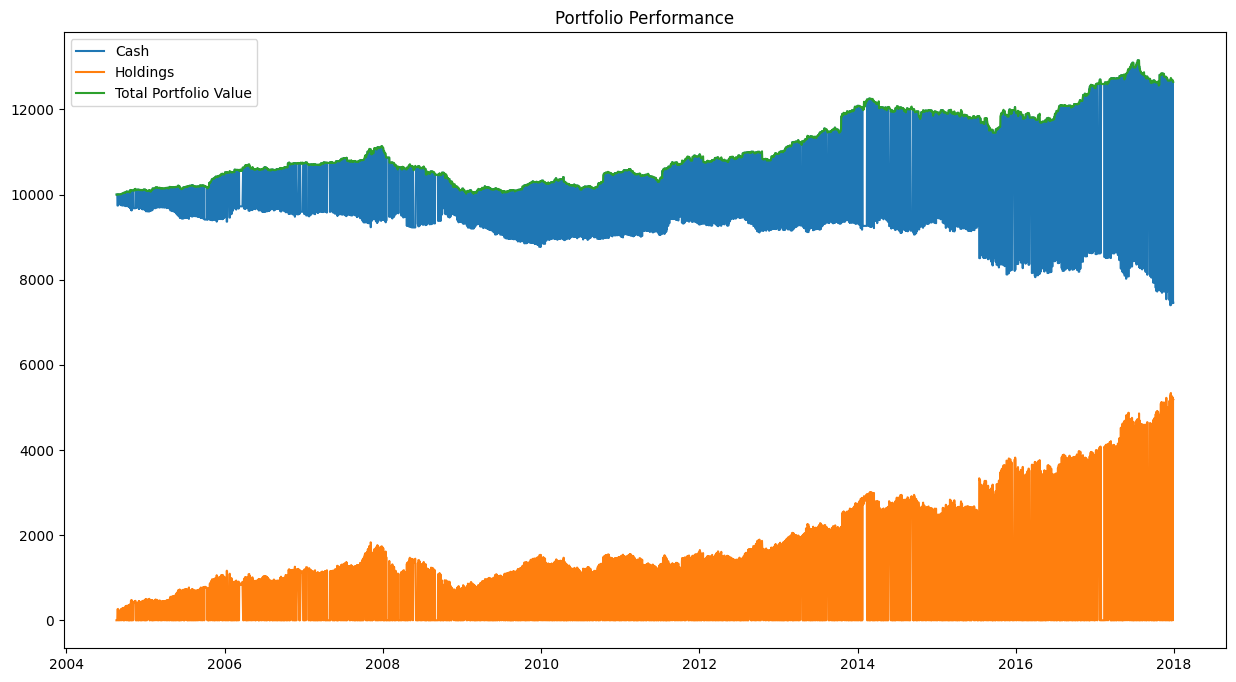

In [8]:
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(portfolio.index, portfolio['cash'], label='Cash')
ax.plot(portfolio.index, portfolio['holdings'], label='Holdings')
ax.plot(portfolio.index, portfolio['total'], label='Total Portfolio Value')

ax.set_title('Portfolio Performance')
ax.legend()
plt.show()

In [9]:
print(f'Initial Capital: ${initial_capital:,.2f}')
print(f'Final Cash: ${portfolio['cash'].iloc[-1]:,.2f}')
print(f'Final Holdings: ${portfolio['holdings'].iloc[-1]:,.2f}')
print(f'Final Portfolio Value: ${portfolio['total'].iloc[-1]:,.2f}')

Initial Capital: $10,000.00
Final Cash: $7,459.09
Final Holdings: $5,186.27
Final Portfolio Value: $12,645.37
